# 📊 Threat Shield — Data Loading & Exploratory Analysis

**Project:** Malicious URL Detection System using Machine Learning  
**Dataset:** `malicious_phish.csv` (Kaggle — Manu Siddhartha)  
**Objective:** Load, explore, and visualize the dataset to understand URL distribution, patterns, and characteristics before model training.

---

## 1 · Import Libraries

We use **Pandas** for data manipulation, **Matplotlib / Seaborn** for visualization, and **WordCloud** for generating visual representations of URL text patterns.

In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

# Inline plots for Jupyter
%matplotlib inline

# Aesthetic defaults
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 2 · Load the Dataset

The dataset contains **651,191 URLs** with two columns:
- `url` — the raw web address
- `type` — the label: **benign**, **defacement**, **phishing**, or **malware**

In [17]:
dataset_path = 'Dataset/malicious_phish.csv'

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset not found at '{dataset_path}'. Please verify the path.")

data = pd.read_csv(dataset_path)
print(f"✅ Dataset loaded successfully — {data.shape[0]:,} rows × {data.shape[1]} columns")

✅ Dataset loaded successfully — 651,191 rows × 2 columns


## 3 · Initial Data Inspection

A quick look at the structure, data types, and sample rows to understand what we're working with.

In [18]:
# Shape of the dataset
print(f"Shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
print()

Shape: (651191, 2)
Columns: ['url', 'type']



In [19]:
# First 5 rows
data.head()

,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


In [20]:
# Last 5 rows
data.tail()

,url,type
651186,xbox360.ign.com/objects/850/850402.html,phishing
651187,games.teamxbox.com/xbox-360/1860/Dead-Space/,phishing
651188,www.gamespot.com/xbox360/action/deadspace/,phishing
651189,en.wikipedia.org/wiki/Dead_Space_(video_game),phishing
651190,www.angelfire.com/goth/devilmaycrytonite/,phishing


In [21]:
# Data types and non-null counts
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 651191 entries, 0 to 651190
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   url     651191 non-null  str  
 1   type    651191 non-null  str  
dtypes: str(2)
memory usage: 9.9 MB


In [22]:
# Check for missing values
print("Missing values per column:")
print(data.isnull().sum())
print(f"\nTotal missing values: {data.isnull().sum().sum()}")

Missing values per column:
url     0
type    0
dtype: int64

Total missing values: 0


In [23]:
# Check for duplicates
duplicates = data.duplicated().sum()
print(f"Duplicate rows: {duplicates:,}")
print(f"Unique URLs: {data['url'].nunique():,} out of {len(data):,}")

Duplicate rows: 10,066
Unique URLs: 641,119 out of 651,191


## 4 · Class Distribution Analysis

Understanding the balance between URL categories is crucial — class imbalance can significantly affect model performance.

In [24]:
# Class counts and percentages
class_counts = data['type'].value_counts()
class_pct = data['type'].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_pct.round(2)})
dist_df

,Count,Percentage (%)
type,,
benign,428103,65.74
defacement,96457,14.81
phishing,94111,14.45
malware,32520,4.99


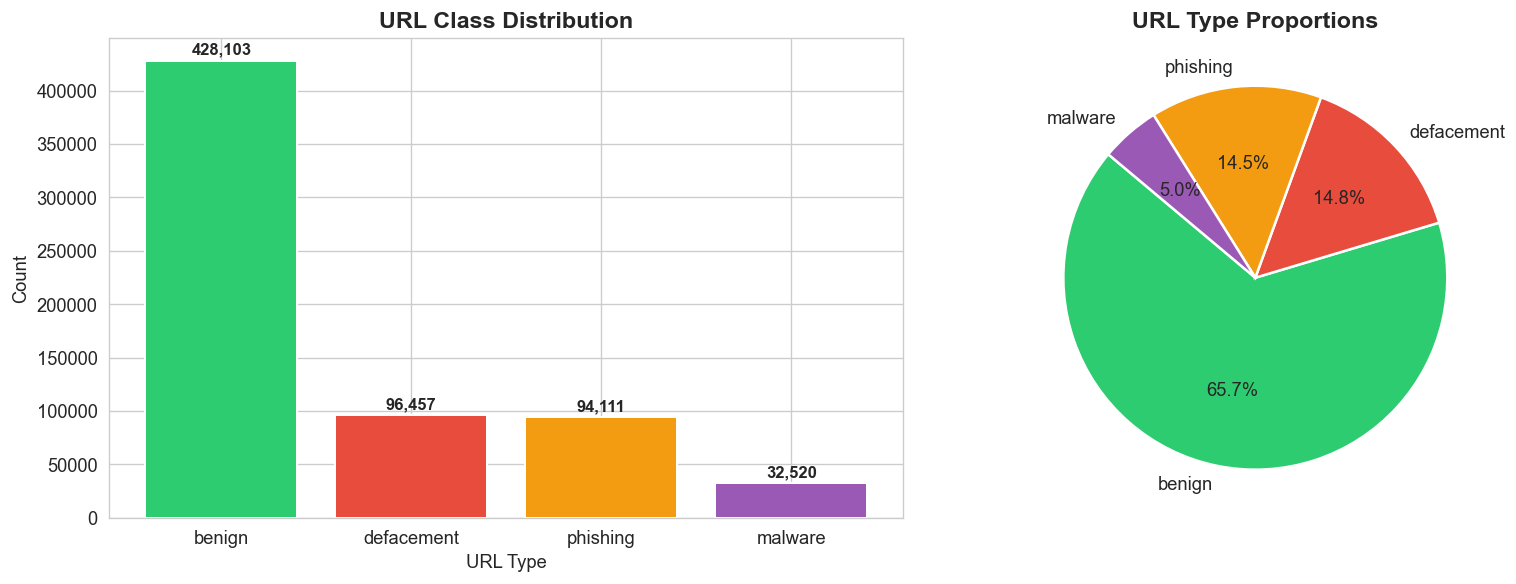

In [25]:
# --- Bar Chart: Class Distribution ---
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('URL Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('URL Type')
axes[0].set_ylabel('Count')
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 11},
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('URL Type Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Key Insight:** The dataset is *imbalanced* — benign URLs dominate (~66.8%), while malware URLs are the minority class. This imbalance is intentional and mirrors real-world internet traffic, but must be accounted for during model training (e.g., stratified splitting).

## 5 · URL Length Analysis

URL length is one of the most discriminative features — malicious URLs tend to be longer due to obfuscation techniques, encoded parameters, and nested redirections.

In [26]:
# Compute URL lengths
data['url_length'] = data['url'].apply(len)

# Summary statistics by class
data.groupby('type')['url_length'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
benign,428103.0,57.7,44.3,6.0,31.0,46.0,71.0,2175.0
defacement,96457.0,86.3,41.9,17.0,55.0,81.0,105.0,327.0
malware,32520.0,56.5,28.4,7.0,33.0,49.0,76.0,378.0
phishing,94111.0,45.9,43.8,1.0,25.0,35.0,49.0,1779.0


/var/folders/7h/j__x1p4s0hl1zcf3j695bkx80000gn/T/ipykernel_3301/2978723576.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='url_length', data=data, order=order, palette=colors, ax=ax,


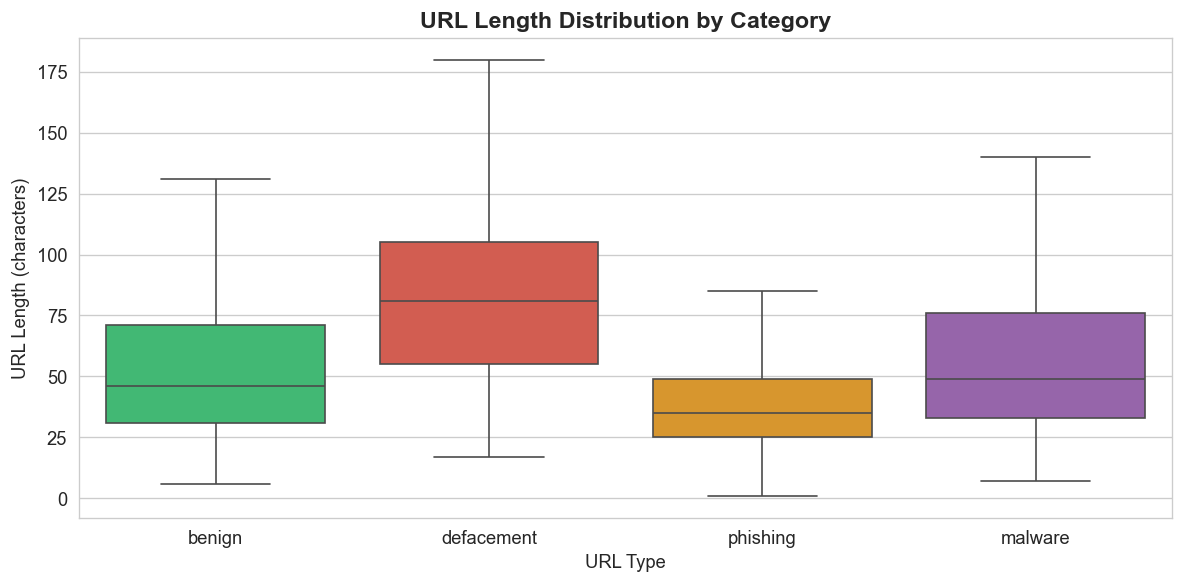

In [27]:
# --- Boxplot: URL Length by Type ---
fig, ax = plt.subplots(figsize=(10, 5))
order = ['benign', 'defacement', 'phishing', 'malware']
sns.boxplot(x='type', y='url_length', data=data, order=order, palette=colors, ax=ax,
            showfliers=False)  # hide extreme outliers for clarity
ax.set_title('URL Length Distribution by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('URL Type')
ax.set_ylabel('URL Length (characters)')
plt.tight_layout()
plt.show()

## 6 · Word Cloud Visualizations

Word clouds reveal the most frequent **tokens** inside URLs for each category. This helps us visually identify domain keywords, suspicious terms, and structural patterns unique to each class.

In [28]:
def generate_wordcloud(text_data, title):
    """Generate and display a word cloud from text data."""
    wordcloud = WordCloud(
        width=1600,
        height=800,
        colormap='Paired',
        background_color='black',
        stopwords=STOPWORDS
    ).generate(text_data)

    plt.figure(figsize=(14, 7), facecolor='k')
    plt.title(title, color='white', fontsize=18, fontweight='bold', pad=15)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.tight_layout(pad=0)
    plt.show()

/var/folders/7h/j__x1p4s0hl1zcf3j695bkx80000gn/T/ipykernel_3301/197850936.py:15: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout(pad=0)
/Users/swatambrasahu/IGDTUW/2nd_sem/ITWorkshop2/Malicious-URL-Detection/env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


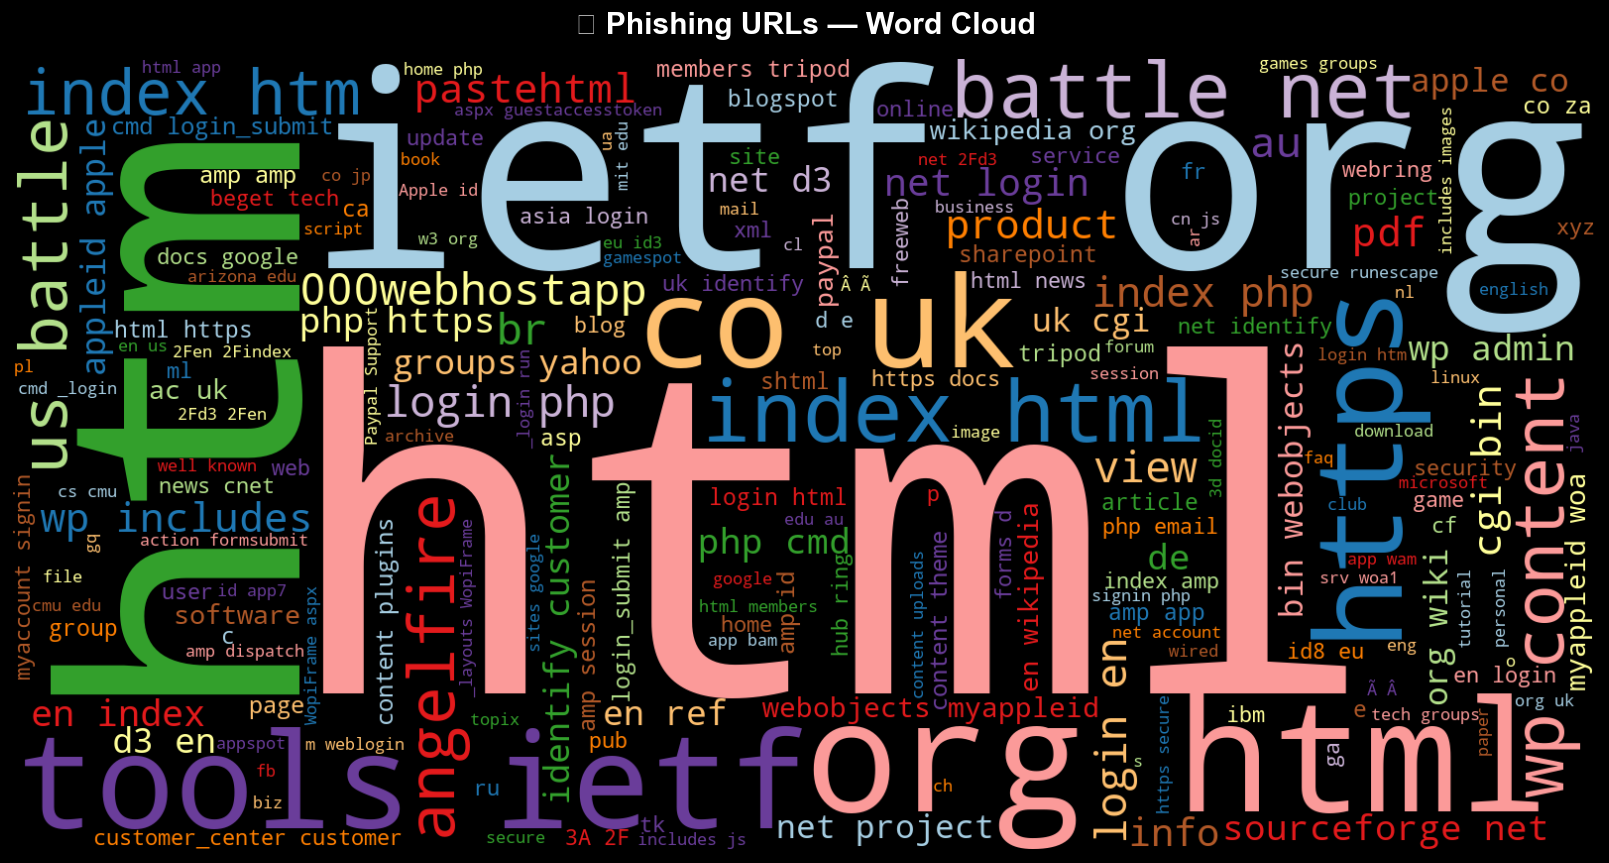

/var/folders/7h/j__x1p4s0hl1zcf3j695bkx80000gn/T/ipykernel_3301/197850936.py:15: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout(pad=0)
/Users/swatambrasahu/IGDTUW/2nd_sem/ITWorkshop2/Malicious-URL-Detection/env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


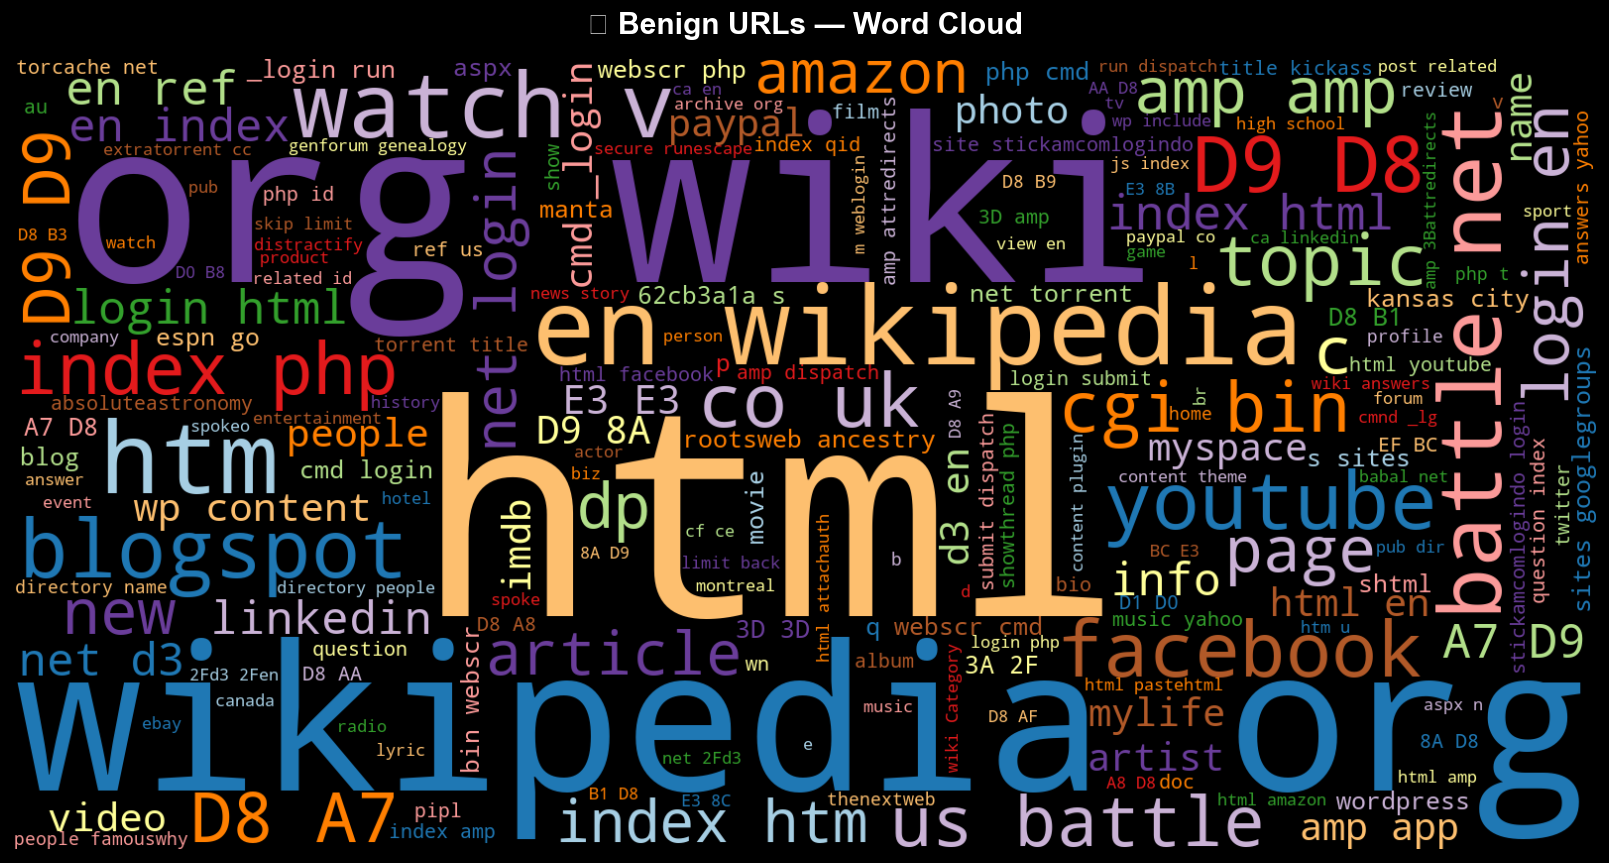

/var/folders/7h/j__x1p4s0hl1zcf3j695bkx80000gn/T/ipykernel_3301/197850936.py:15: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout(pad=0)
/Users/swatambrasahu/IGDTUW/2nd_sem/ITWorkshop2/Malicious-URL-Detection/env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


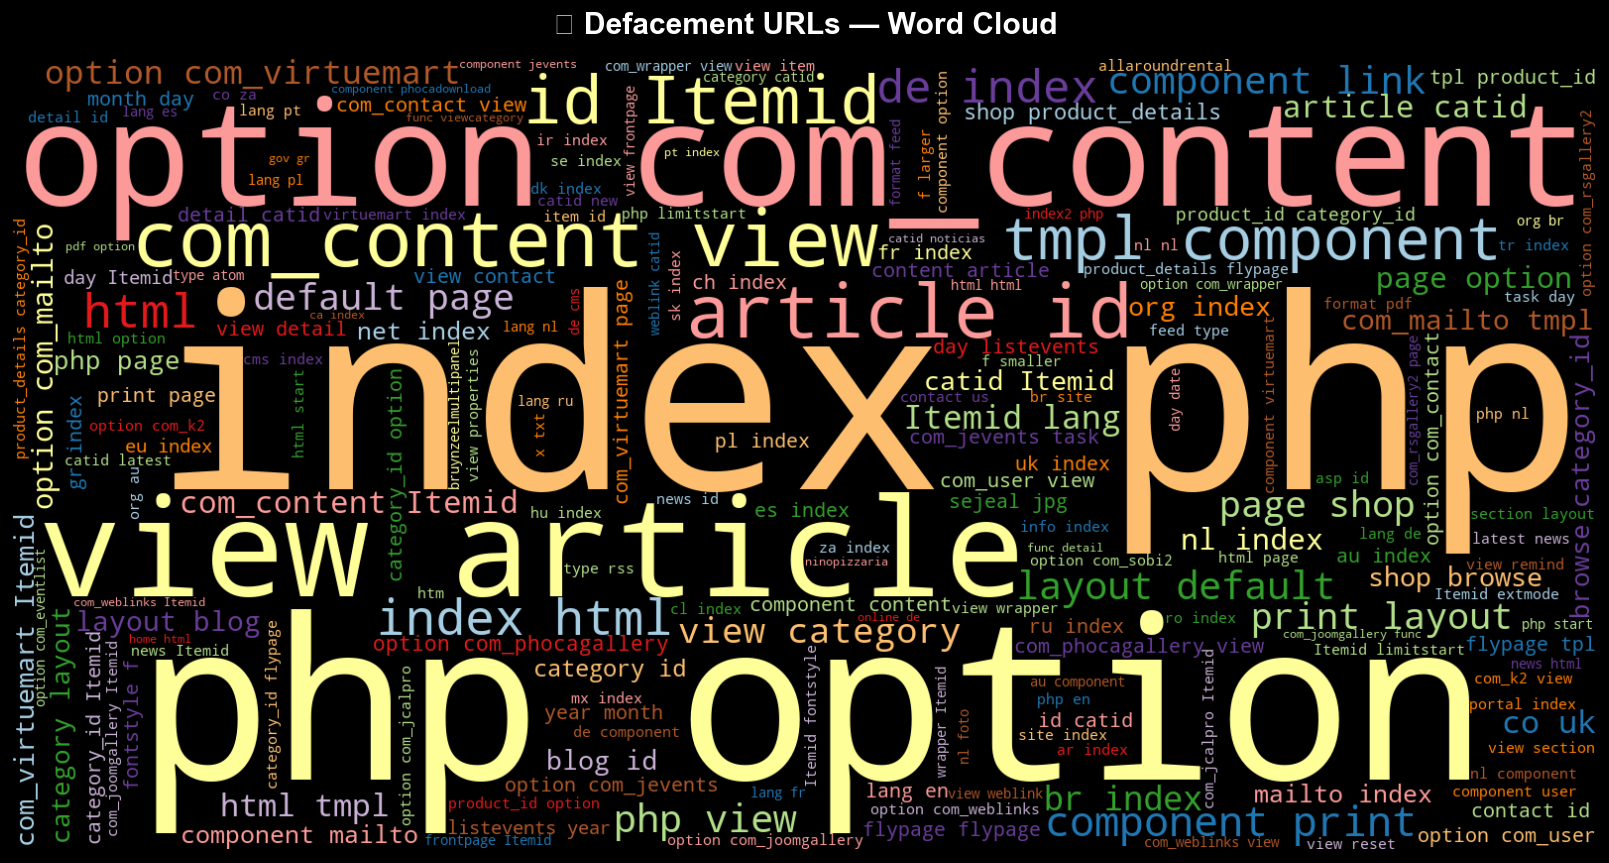

/var/folders/7h/j__x1p4s0hl1zcf3j695bkx80000gn/T/ipykernel_3301/197850936.py:15: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout(pad=0)
/Users/swatambrasahu/IGDTUW/2nd_sem/ITWorkshop2/Malicious-URL-Detection/env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


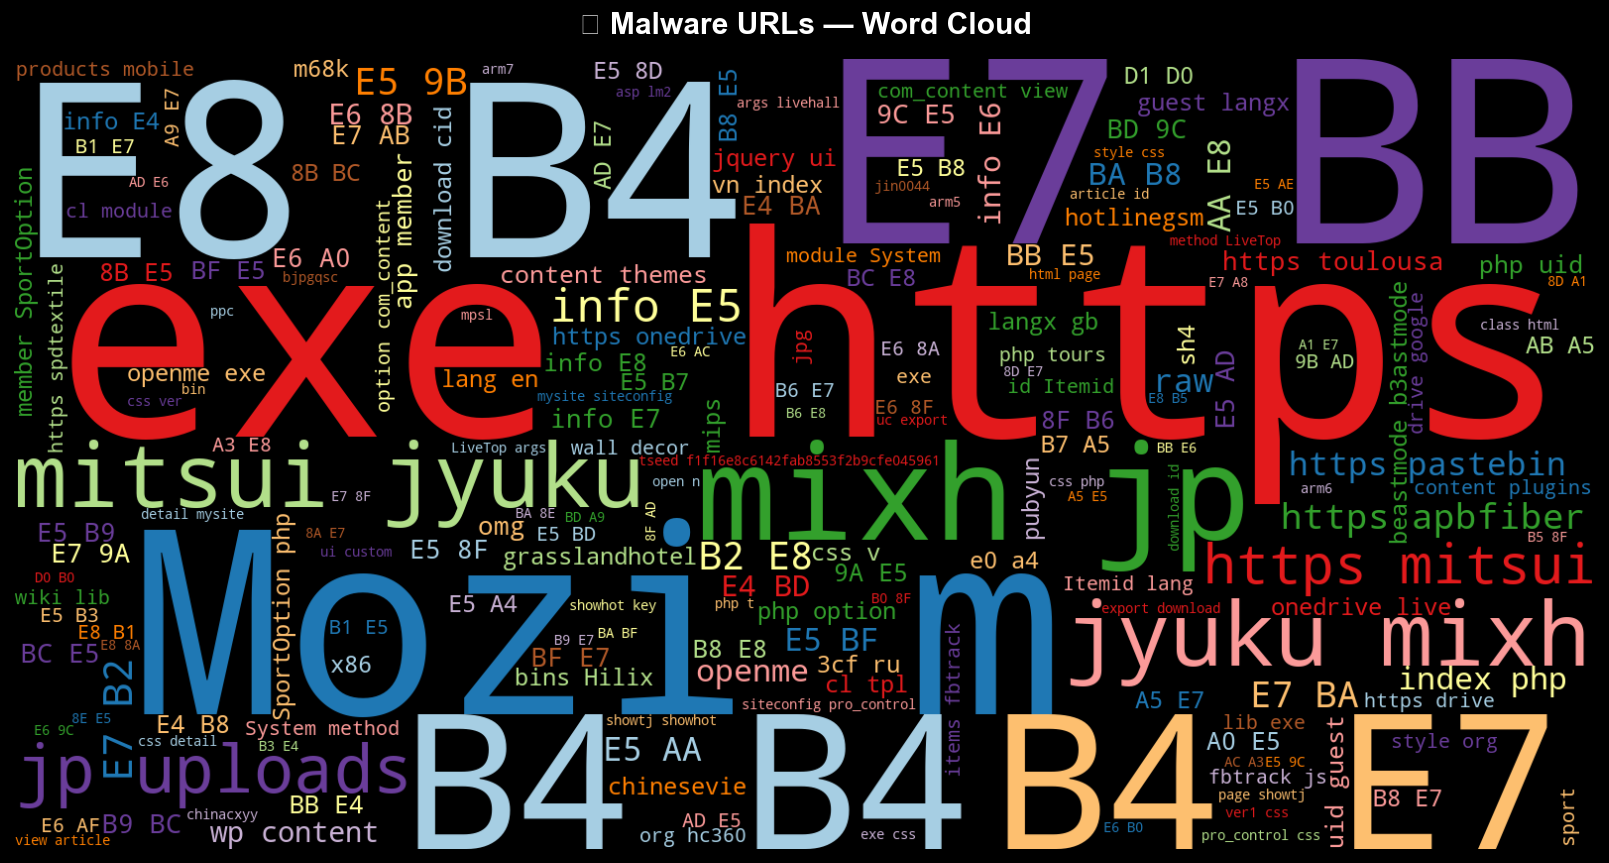

In [29]:
# Generate a word cloud for each URL category
categories = data['type'].unique()

for category in categories:
    subset = data[data['type'] == category]
    text = " ".join(subset['url'].astype(str))
    generate_wordcloud(text, f"🔍 {category.capitalize()} URLs — Word Cloud")

## 7 · Quick Statistical Summary

A compact overview of the dataset to wrap up the exploratory phase.

In [30]:
# --- Summary Table ---
summary = {
    'Total URLs': f"{len(data):,}",
    'Unique URLs': f"{data['url'].nunique():,}",
    'Duplicate URLs': f"{data.duplicated().sum():,}",
    'URL Categories': ', '.join(data['type'].unique()),
    'Avg URL Length': f"{data['url_length'].mean():.1f} characters",
    'Max URL Length': f"{data['url_length'].max():,} characters",
    'Missing Values': str(data.isnull().sum().sum())
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
summary_df.style.hide(axis='index').set_properties(**{
    'text-align': 'left',
    'font-size': '12px'
})

Metric,Value
Total URLs,"651,191"
Unique URLs,"641,119"
Duplicate URLs,"10,066"
URL Categories,"phishing, benign, defacement, malware"
Avg URL Length,60.2 characters
Max URL Length,"2,175 characters"
Missing Values,0


---

## 📌 Conclusion

| Observation | Detail |
|:---|:---|
| **Dataset size** | 651,191 URLs across 4 categories |
| **Class imbalance** | Benign URLs dominate (~66.8%), malware is the smallest class |
| **Data quality** | No missing values; ~10K duplicates to be removed during preprocessing |
| **URL length** | Malicious URLs tend to be longer — useful as a discriminative feature |
| **Word clouds** | Reveal distinct keyword patterns per category (e.g., "login", "account" in phishing) |

**Next step →** Feature engineering and model training in `MaliciousURLDetection.ipynb`

---
*Threat Shield — IGDTUW IT Workshop Project*